In [1]:
#import keras
import tensorflow as tf
from tensorflow import keras
from IPython.display import Image
import matplotlib.pyplot as plt
#from keras import layers
#from keras import ops
from tensorflow.keras import layers
import os
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
from keras.callbacks import CSVLogger
from PIL import Image
import seaborn as sns
import json
import tqdm
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

2026-05-06 17:41:47.659672: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


<h1>Analyzing the dataset</h1>

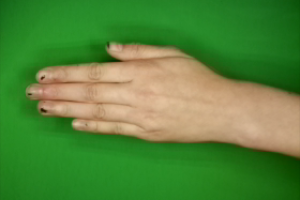

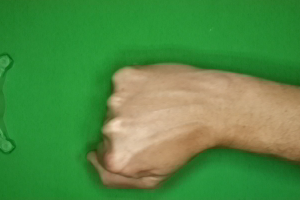

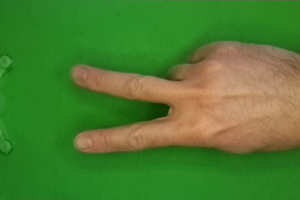

In [2]:
paper= Image.open('./train/paper/2IOsxsG8AaxntdJM.png')
paper.show()
rock= Image.open('./train/rock/2DdERUV7Te8ivywq.png')
rock.show()
scissors= Image.open('./train/scissors/2DEYFsJ27UgVqv3W.png')
scissors.show()


In [3]:

train_ds = tf.keras.utils.image_dataset_from_directory(
    "rps-cv-images",
    validation_split=0.30,
    subset="training",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    "rps-cv-images",
    validation_split=0.30,
    subset="validation",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

temp_size = len(temp_ds)

val_size = temp_size // 2

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)


Found 2188 files belonging to 3 classes.
Using 1532 files for training.


I0000 00:00:1778082115.137299    2037 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7535 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:07:00.0, compute capability: 8.6


Found 2188 files belonging to 3 classes.
Using 656 files for validation.


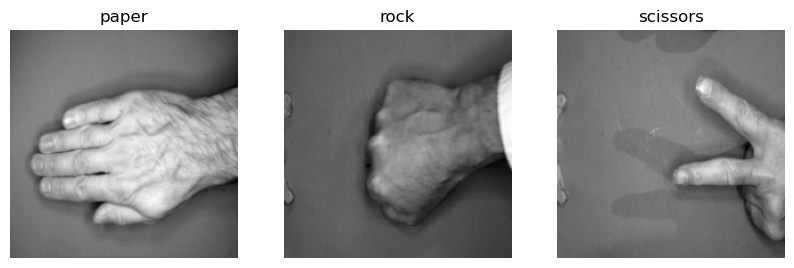

In [4]:
class_names = train_ds.class_names
# Display one image per class
shown_classes = set()
plt.figure(figsize=(10, 4))
for images, labels in train_ds.unbatch():
    label = labels.numpy()
    if label not in shown_classes:
        plt.subplot(1, len(class_names), len(shown_classes) + 1)
        plt.imshow(images.numpy().squeeze(), cmap="gray")  
        plt.title(class_names[label])
        plt.axis("off")
        shown_classes.add(label)
    if len(shown_classes) == len(class_names):
        break
plt.show()

<h2>Model 1 architecture and training</h2>

In [5]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1, 0.1)
])

In [6]:

if os.path.exists("model_1.keras"):
    model_1 = keras.models.load_model("model_1.keras")
    history_1 = pd.read_csv('./training_1.log',sep=',',engine='python')
else:
    model_1 = keras.Sequential(
        [
        
        layers.Rescaling(1./255),
        layers.Resizing(96, 96),        
       layers.Conv2D(16, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(96, 96, 1)),
       layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu",kernel_initializer='he_normal'),
        layers.Dense(3,activation='softmax')
    
        ]
    )
    csv_logger_1 = CSVLogger('training_1.log', separator=',', append=False)
    model_1.summary()
    model_1.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    history_1=model_1.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=[csv_logger_1])
    history_1=history_1.history

Index(['epoch', 'accuracy', 'loss', 'val_accuracy', 'val_loss'], dtype='object')


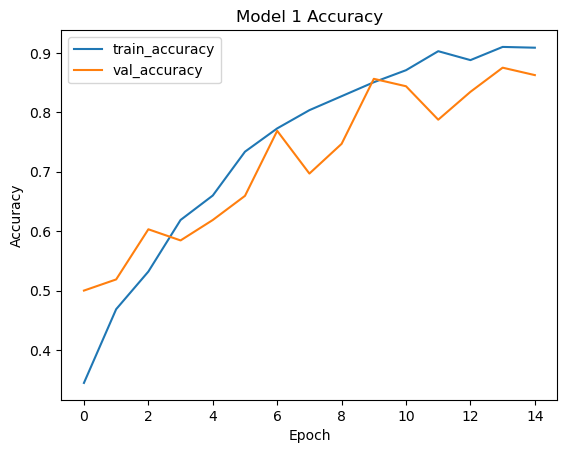

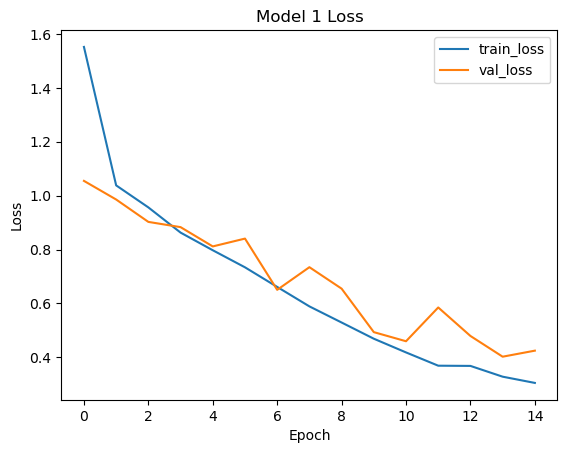

In [7]:
print(history_1.keys())
plt.title("Model 1 Accuracy")
plt.plot(history_1["accuracy"], label="train_accuracy")
plt.plot(history_1["val_accuracy"], label="val_accuracy")
#plt.ylim(0.8, 1.0) 
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
plt.title("Model 1 Loss")
plt.plot(history_1["loss"], label="train_loss")
plt.plot(history_1["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

<h3>Model 1 prediction</h3> 

2026-05-06 17:41:58.607270: I external/local_xla/xla/service/service.cc:163] XLA service 0x7b05d4006c50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-06 17:41:58.607300: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2026-05-06 17:41:58.645930: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-06 17:41:58.726075: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted label: paper
Actual label: paper


I0000 00:00:1778082119.801635    2212 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


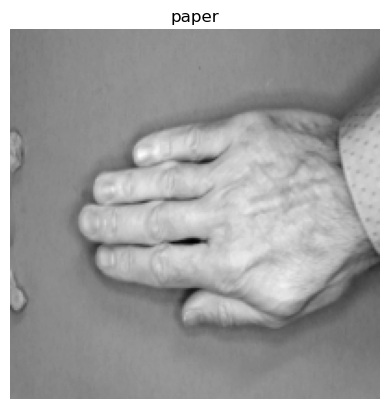

2026-05-06 17:41:59.893935: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_1.predict(image[None, ...])

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

<h2>Model 2 architecture and training</h2>

In [9]:

if os.path.exists("model_2.keras"):
    model_2 = keras.models.load_model("model_2.keras")
    history_2 = pd.read_csv('./training_2.log',sep=',',engine='python')
else:
    model_2 = keras.Sequential(
        [
            data_augmentation,
        layers.Rescaling(1./255),
       layers.Conv2D(32, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(128, 128, 1)),
       layers.MaxPooling2D((2, 2)),
       layers.Conv2D(64, (3, 3), activation="relu",kernel_initializer='he_normal'),
       layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu",kernel_initializer='he_normal'),
        layers.Dense(64, activation="relu",kernel_initializer='he_normal'),

        layers.Dense(3,activation='softmax')

        ]
    )
    csv_logger_2 = CSVLogger('training_2.log', separator=',', append=False)
    model_2.summary()

    model_2.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history_2=model_2.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=[csv_logger_2])
    history_2=history_2.history

Index(['epoch', 'accuracy', 'loss', 'val_accuracy', 'val_loss'], dtype='object')


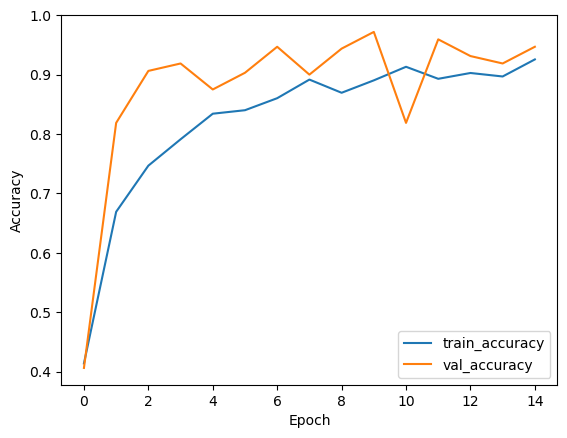

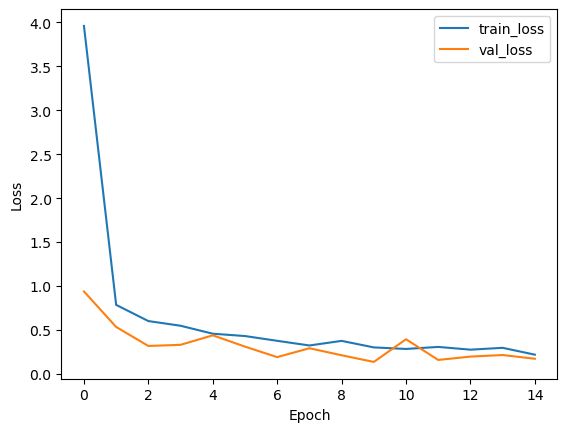

In [10]:
print(history_2.keys())
plt.plot(history_2["accuracy"], label="train_accuracy")
plt.plot(history_2["val_accuracy"], label="val_accuracy")
#plt.ylim(0.9, 1.0) 
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
plt.plot(history_2["loss"], label="train_loss")
plt.plot(history_2["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

<h3>Model 2 prediction </h3>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step
Predicted label: rock
Actual label: rock


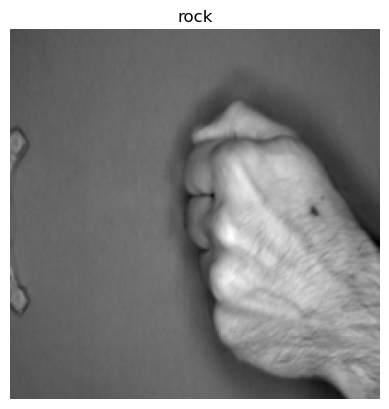

2026-05-06 17:42:02.479824: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [11]:
for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_2.predict(image[None, ...])
    

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

<h2>Model 3 architecture and training</h2>

<h3>Finding The best learning rate using grid-search</h3>

In [12]:

if os.path.exists("best_lr.json"):
    best_params = json.load(open('best_lr.json', 'r'))
    best_lr = best_params['best_lr']
    best_val_acc = best_params['best_val_acc']
else:
    lr_arr=[1e-5,2e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3]
    best_val_acc = 0
    best_lr = None
    for lr in lr_arr:
        model_4 = keras.Sequential([
            data_augmentation,
            layers.Rescaling(1./255),

            layers.Conv2D(32, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(200, 200, 1)),
            layers.MaxPooling2D((2, 2)), 

            layers.Conv2D(64, (3, 3), activation="relu",kernel_initializer='he_normal'),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(128, (3, 3), activation='relu',kernel_initializer='he_normal'),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(256, (3, 3), activation='relu',kernel_initializer='he_normal'),
            layers.MaxPooling2D((2, 2)),


            layers.Flatten(),
            layers.Dense(1024, activation="relu",name='dense_1',kernel_initializer='he_normal'),
            layers.Dropout(0.2),
            layers.Dense(3, activation='softmax')
        ])

        model_4.compile(
            optimizer=keras.optimizers.Adam(learning_rate=lr),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]

        )
        
        history_4=model_4.fit(train_ds, validation_data=val_ds, epochs=15)
        history_4=history_4.history

        # Update best learning rate if current model performs better
        if max(history_4['val_accuracy'])  > best_val_acc:
            best_val_acc = max(history_4['val_accuracy'])
            best_lr = lr
    json.dump({'best_lr': best_lr, 'best_val_acc': best_val_acc}, open('best_lr.json', 'w'))


In [13]:
early_stop = EarlyStopping(
    monitor='val_accuracy',   # or 'val_loss'
    mode='max',
    patience=3,
    restore_best_weights=True
)

lr_sched = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)


ckpt = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

In [14]:
if os.path.exists("model_3.keras"):
    model_3 = keras.models.load_model("model_3.keras")
    history_3 = pd.read_csv('./training_3.log',sep=',',engine='python')
else:
    model_3 = keras.Sequential([

        data_augmentation,
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(200, 200, 1)),
        layers.MaxPooling2D((2, 2)), 

        layers.Conv2D(64, (3, 3), activation="relu",kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu',kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu',kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),
       

        layers.Flatten(),
        layers.Dense(512, activation="relu",name='dense_1',kernel_initializer='he_normal'),
        layers.Dropout(0.2),
        layers.Dense(3, activation='softmax')
    ])
    csv_logger_3 = CSVLogger('training_3.log', separator=',', append=False)

    model_3.summary()
    model_3.compile(
        optimizer=keras.optimizers.Adam(learning_rate=best_lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
        
    )
    history_3=model_3.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=[csv_logger_3, early_stop, lr_sched, ckpt])
    history_3=history_3.history

Index(['epoch', 'accuracy', 'loss', 'val_accuracy', 'val_loss'], dtype='object')


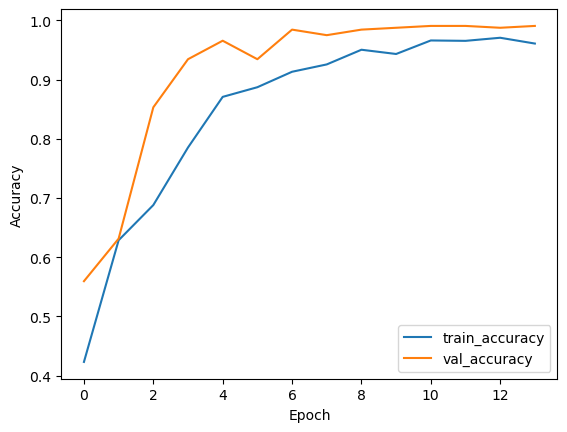

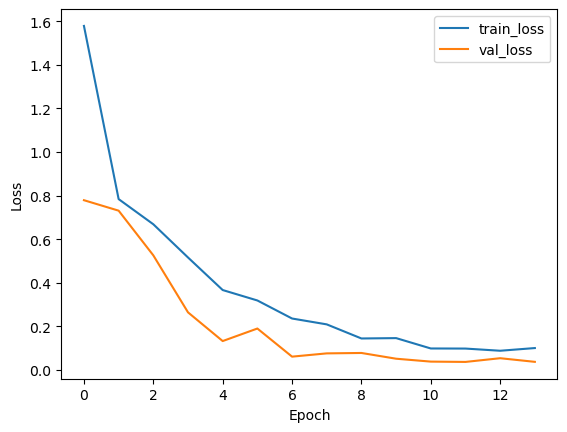

In [15]:
print(history_3.keys())
plt.plot(history_3["accuracy"], label="train_accuracy")
plt.plot(history_3["val_accuracy"], label="val_accuracy")
#plt.ylim(0.9, 1.0) 
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
plt.plot(history_3["loss"], label="train_loss")
plt.plot(history_3["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

<h3>Model 3 prediction</h3>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
Predicted label: scissors
Actual label: scissors


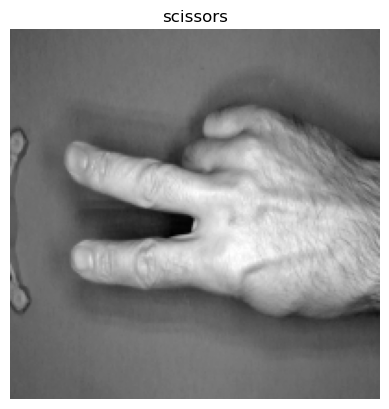

In [16]:

for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_3.predict(image[None, ...])
    

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()
    

<h2>Models testing</h2>

In [17]:
y_test=[]
img_test=[]
y_pred_1=[]
y_pred_2=[]
y_pred_3=[]
for images, labels in test_ds.unbatch():
    y_test.append(labels.numpy())
    img_test.append(images.numpy())
    y_pred_1.append(np.argmax(model_1.predict(images[None, ...])[0]))
    y_pred_2.append(np.argmax(model_2.predict(images[None, ...])[0]))
    y_pred_3.append(np.argmax(model_3.predict(images[None, ...])[0]))

y_test = np.array(y_test)
img_test = np.array(img_test)
y_pred_1 = np.array(y_pred_1)
y_pred_2 = np.array(y_pred_2)
y_pred_3 = np.array(y_pred_3)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

2026-05-06 17:42:53.560379: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


<h2>Performance evaluation</h2>

In [18]:
result_1=confusion_matrix(y_test, y_pred_1,labels=[0,1,2])

In [19]:
incorrect_indices_1 = np.where(y_pred_1 != y_test)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_1)} out of {len(y_test)}")

Incorrectly classified samples: 50 out of 336


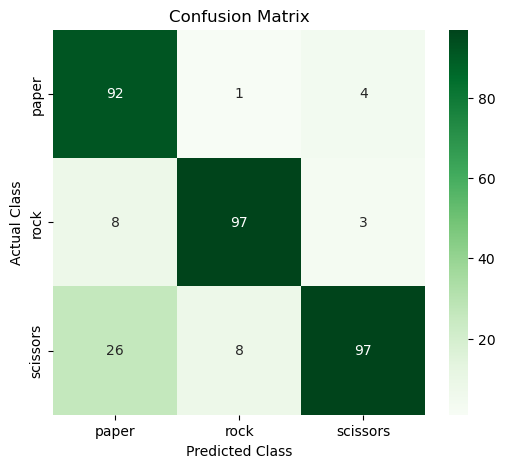

In [20]:
p=[('Predicted', x)  for x in class_names]
b=[('Actual', x)  for x in class_names]
df = pd.DataFrame(result_1, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model1_cf=np.array(pd.DataFrame(result_1,columns=class_names,index=class_names))
plt.figure(figsize=(6,5))
sns.heatmap(result_1, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step


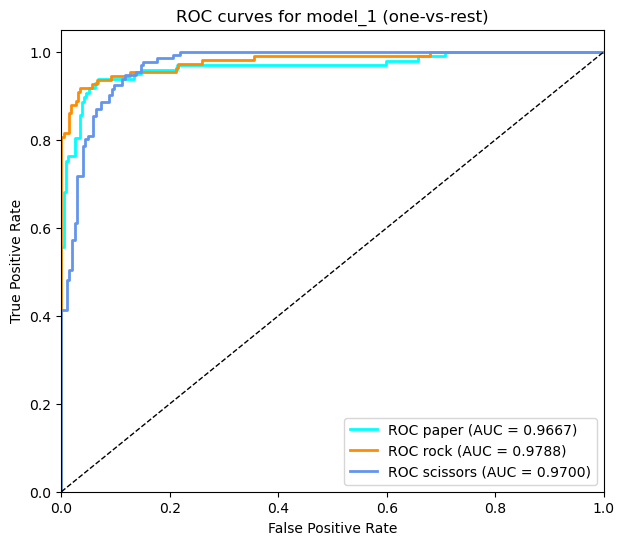

AUC per class:
  paper: 0.9667
  rock: 0.9788
  scissors: 0.9700
Micro AUC: 0.9609
Macro AUC: 0.9718


In [ ]:
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

n_classes = len(class_names)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# If model_1 needs 96x96 and you want to resize explicitly, uncomment:
# img_test_resized = tf.image.resize(img_test, (96, 96)).numpy()
# y_score = model_1.predict(img_test_resized)

y_score = model_1.predict(img_test)  # predicted probabilities

fpr = dict(); tpr = dict(); roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

roc_auc["micro"] = roc_auc_score(y_test_bin, y_score, average="micro", multi_class="ovr")
roc_auc["macro"] = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")

colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
plt.figure(figsize=(7,6))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC {class_names[i]} (AUC = {roc_auc[i]:.4f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlim([0.0,1.0]); plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC curves for model_1 (one-vs-rest)')
plt.legend(loc='lower right')
plt.show()

print('AUC per class:')
for i in range(n_classes):
    print(f'  {class_names[i]}: {roc_auc[i]:.4f}')
print(f"Micro AUC: {roc_auc['micro']:.4f}")
print(f"Macro AUC: {roc_auc['macro']:.4f}")


In [21]:
result_2=confusion_matrix(y_test, y_pred_2)

In [22]:
incorrect_indices_2 = np.where(y_pred_2 != y_test)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_2)} out of {len(y_test)}")

Incorrectly classified samples: 17 out of 336


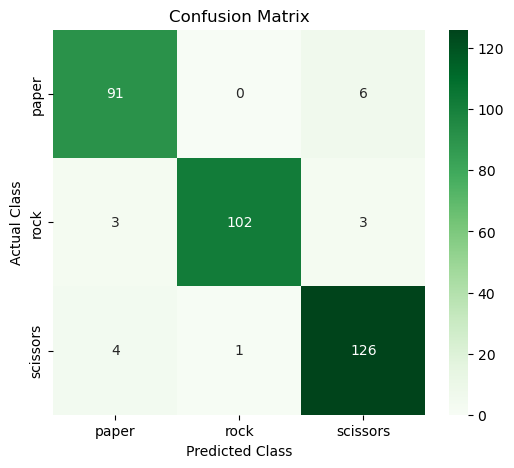

In [23]:
p=[('Predicted', x)  for x in class_names]
b=[('Real', x)  for x in class_names]
df = pd.DataFrame(result_2, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model2_cf=np.array(pd.DataFrame(result_2,columns=class_names,index=class_names))

plt.figure(figsize=(6,5))
sns.heatmap(result_2, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


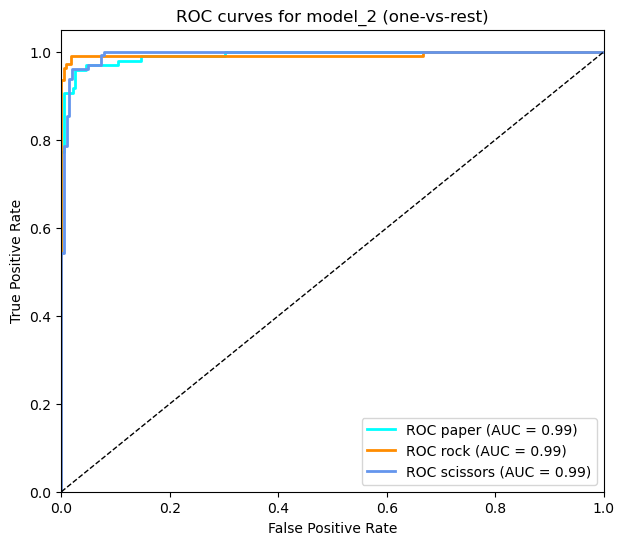

AUC per class:
  paper: 0.9920
  rock: 0.9933
  scissors: 0.9938
Micro AUC: 0.9923
Macro AUC: 0.9930


In [40]:
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

n_classes = len(class_names)
y_test_bin = label_binarize(y_test, classes=range(n_classes))
y_score = model_2.predict(img_test)  # predicted probabilities

fpr = dict(); tpr = dict(); roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

roc_auc["micro"] = roc_auc_score(y_test_bin, y_score, average="micro", multi_class="ovr")
roc_auc["macro"] = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")

colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
plt.figure(figsize=(7,6))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC {class_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlim([0.0,1.0]); plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC curves for model_2 (one-vs-rest)')
plt.legend(loc='lower right')
plt.show()

print('AUC per class:')
for i in range(n_classes):
    print(f'  {class_names[i]}: {roc_auc[i]:.4f}')
print(f"Micro AUC: {roc_auc['micro']:.4f}")
print(f"Macro AUC: {roc_auc['macro']:.4f}")

In [24]:

result_3=confusion_matrix(y_test, y_pred_3)

In [25]:
incorrect_indices_3 = np.where(y_pred_3 != y_test)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_3)} out of {len(y_test)}")


Incorrectly classified samples: 2 out of 336


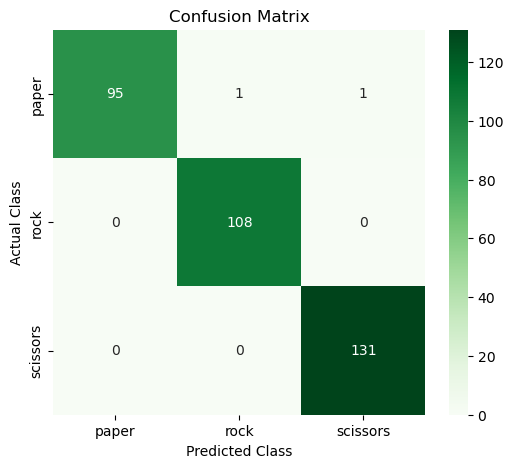

In [26]:
p=[('Predicted', x)  for x in class_names]
b=[('Real', x)  for x in class_names]
df = pd.DataFrame(result_3, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model3_cf=np.array(pd.DataFrame(result_3,columns=class_names,index=class_names))

plt.figure(figsize=(6,5))
sns.heatmap(result_3, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 540ms/step


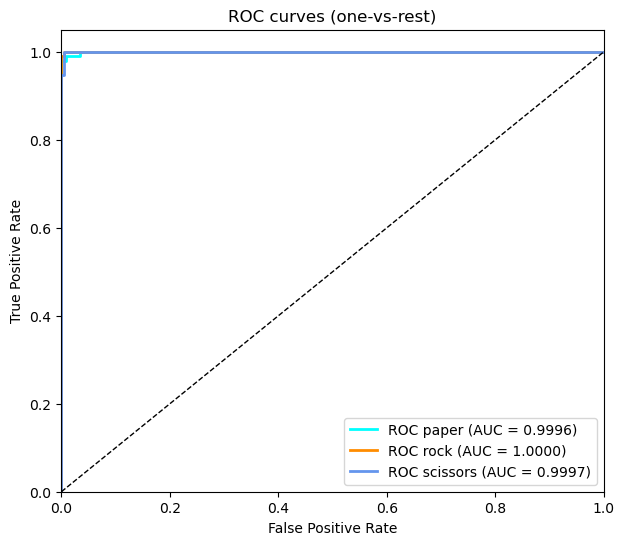

AUC per class:
  paper: 0.9996
  rock: 1.0000
  scissors: 0.9997
Micro AUC: 0.9999
Macro AUC: 0.9998


In [39]:
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# number of classes
n_classes = 3

# binarize true labels (shape: [n_samples, n_classes])
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# predicted probabilities from the model (model already includes Rescaling)
y_score = model_3.predict(img_test)  # shape: (n_samples, n_classes)

# compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes): #One vs rest approach, treat class i as positive and the rest as negative
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# micro- and macro-averaged AUC (multiclass)
#micro auc: aggregates contributions from all classes and computes a global average
# macro auc: computes AUC for each class and averages them, treating all classes equally regardless of their frequency  
roc_auc["micro"] = roc_auc_score(y_test_bin, y_score, average="micro", multi_class="ovr")
roc_auc["macro"] = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")

# Plot per-class ROC
colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
plt.figure(figsize=(7,6))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC {class_names[i]} (AUC = {roc_auc[i]:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC curves (one-vs-rest)')
plt.legend(loc='lower right')
plt.show()

# Print summary AUCs
print('AUC per class:')
for i in range(n_classes):
    print(f'  {class_names[i]}: {roc_auc[i]:.4f}')
print(f"Micro AUC: {roc_auc['micro']:.4f}")
print(f"Macro AUC: {roc_auc['macro']:.4f}")

<h2>Incorrect prediction analisys</h2>

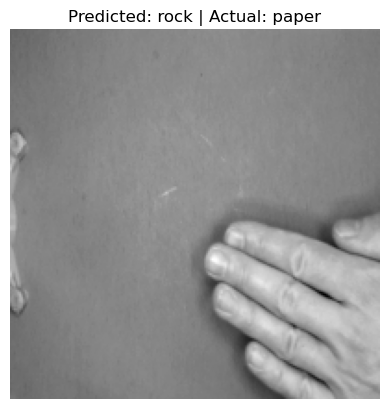

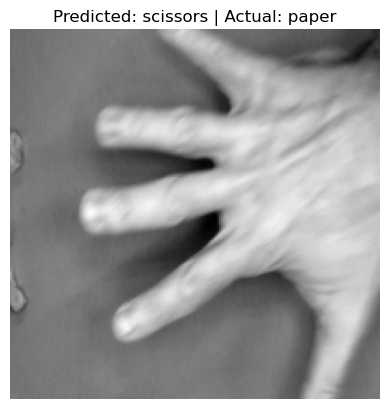

In [27]:
for idx in incorrect_indices_3:
    img=img_test[idx].squeeze()
    plt.imshow(img, cmap="gray")
    plt.title(f'Predicted: {class_names[y_pred_3[idx]]} | Actual: {class_names[y_test[idx]]}')
    plt.axis("off")
    plt.show()

<h3>Performance metrics</h3>

In [28]:
m1_true_pos=np.diag(model1_cf)
m1_false_pos=np.sum(model1_cf, axis=0)-m1_true_pos
m1_false_neg=np.sum(model1_cf, axis=1)-m1_true_pos
m1_true_neg=np.sum(model1_cf)-m1_true_pos-m1_false_pos-m1_false_neg

m1_precision =m1_true_pos / (m1_true_pos + m1_false_pos)
m1_recall =m1_true_pos / (m1_true_pos + m1_false_neg)
m1_accuracy = np.sum(m1_true_pos) / np.sum(model1_cf)
m1_f1_score = 2 * (m1_precision * m1_recall) / (m1_precision + m1_recall)




In [29]:
print(f'------------------------model 1 performance metrics------------------------')
print(f'precision = {np.mean(m1_precision)}')
print(f'recall = {np.mean(m1_recall)}')
print(f'accuracy = {m1_accuracy}')
print(f'f1_score = {np.mean(m1_f1_score)}')


------------------------model 1 performance metrics------------------------
precision = 0.8593151258245598
recall = 0.8623532572209154
accuracy = 0.8511904761904762
f1_score = 0.8523953595305672


In [30]:
m2_true_pos=np.diag(model2_cf)
m2_false_pos=np.sum(model2_cf, axis=0)-m2_true_pos
m2_false_neg=np.sum(model2_cf, axis=1)-m2_true_pos
m2_true_neg=np.sum(model2_cf)-m2_true_pos-m2_false_pos-m2_false_neg


m2_precision =m2_true_pos / (m2_true_pos + m2_false_pos)
m2_recall =m2_true_pos / (m2_true_pos + m2_false_neg)
m2_accuracy = np.sum(m2_true_pos) / np.sum(model2_cf)
m2_f1_score = 2 * (m2_precision * m2_recall) / (m2_precision + m2_recall)




In [31]:
print(f'------------------------model 2 performance metrics------------------------')
print(f'precision = {np.mean(m2_precision)}')
print(f'recall = {np.mean(m2_recall)}')
print(f'accuracy = {m2_accuracy}')
print(f'f1_score = {np.mean(m2_f1_score)}')


------------------------model 2 performance metrics------------------------
precision = 0.9507320080135614
recall = 0.948140278470018
accuracy = 0.9494047619047619
f1_score = 0.9491754663119093


In [32]:
m3_true_pos=np.diag(model3_cf)
m3_false_pos=np.sum(model3_cf, axis=0)-m3_true_pos
m3_false_neg=np.sum(model3_cf, axis=1)-m3_true_pos
m3_true_neg=np.sum(model3_cf)-m3_true_pos-m3_false_pos-m3_false_neg


m3_precision =m3_true_pos / (m3_true_pos + m3_false_pos)
m3_recall =m3_true_pos / (m3_true_pos + m3_false_neg)
m3_accuracy = np.sum(m3_true_pos) / np.sum(model3_cf)
m3_f1_score = 2 * (m3_precision * m3_recall) / (m3_precision + m3_recall)




In [33]:
print(f'------------------------model 3 performance metrics------------------------')
print(f'precision = {np.mean(m3_precision)}')
print(f'recall = {np.mean(m3_recall)}')
print(f'accuracy = {m3_accuracy}')
print(f'f1_score = {np.mean(m3_f1_score)}')

------------------------model 3 performance metrics------------------------
precision = 0.9944166434992123
recall = 0.993127147766323
accuracy = 0.9940476190476191
f1_score = 0.9937242523445454


In [34]:

if not os.path.exists("model_1.keras"):
        model_1.save("model_1.keras")
if not os.path.exists("model_2.keras"):
        model_2.save("model_2.keras")
if not os.path.exists("model_3.keras"):
        model_3.save("model_3.keras")